# PyG Implementation of MeshGraphNets

In this notebook, we run a PyG implementation of MeshGraphNets based on the [Medium blog post](https://medium.com/stanford-cs224w/learning-mesh-based-flow-simulations-on-graph-networks-44983679cf2d), "Learning Mesh-Based Flow Simulations on Graph Networks" and [Colab](https://colab.research.google.com/drive/1mZAWP6k9R0DE5NxPzF8yL2HpIUG3aoDC?usp=sharing) by Isaac Ju, Robert Lupoiu, and Rayan Kanfar. For a more in-depth explanation of the methods and model, please consult their work. 

This code is based on the paper by T. Pfaff et al., [Learning Mesh-Based Simulation with Graph Networks (2021) ICLR](https://arxiv.org/pdf/2010.03409). The original codebase provided by DeepMind is available [here]( https://github.com/deepmind/deepmind-research/tree/master/meshgraphnets).

# Acessing Pre-Processed Datasets

NOTE: TO ACCESS THE DATASETS AND FILES ACCOMPANYING THIS COLAB, PLEASE FOLLOW THE FOLLOWING LINK: https://drive.google.com/drive/folders/12QaYm2Y6H4UJ0dit9us4cfN7HelpLXvD?usp=sharing

In order to access the preprocessed datasets, we will need to implement a little Google Colab workaround in order to access them without downloading them to your own Drive. We will mount the directories used in this Colab to this instance. If you're not sure how to do that, please follow these steps:

1.   Go to the root directory in which this file is located (named MeshGraphNets_PyG)
2.   Right-click on the ./datasets folder and select "Add shortcut to Drive"
3.   Create a shortcut of ./datasets ./animations ./best_models in "My Drive"
4.   Run the cell below and follow the prompts in the pop-up windows. Allow Google Colab to access your Drive so that you it can view the shortcut that you just created.

After completing the steps listed above, you will have access to all of the datasets in the ./datasets folder!

In [1]:
import random
from pathlib import Path
import numpy as np
import torch
import icemesh.model as m
import icemesh.postprocessing as post
import icemesh.preprocessing as prep
import icemesh.train_test as tt

torch.__version__

'2.7.1'

First, we need to define the root directory and dataset directory as well as where to save the checkpoint and animations.

In [2]:
dataset_dir = Path.cwd() / "datasets"
checkpoint_dir = Path.cwd() / "best_models"
animation_dir = Path.cwd() / "animations"
postprocess_dir = Path.cwd() / "2d_loss_plots"

dataset_dir

PosixPath('/Users/clairedonnelly/Documents/IceGraph/icemesh/datasets')

# Preparing and Loading the Dataset

**Data Pre-Processing Code**

We first define the dataset file, as well as the number of timeseps and trajectories we want to process.

Each trajectory has 600 timesteps. Each trajectory (mesh) has a unique connectivity, which is described by cells. Cells has a shape of (**timestep, cell_num, 3**). Each cell is consisted of three vertices whose index is given by querying cell_to_vertex map. Mesh_pos gives a unique set of vertex coordinates.

In [3]:
# Define the data folder and data file name
datafile = Path(dataset_dir, 'valid.h5')

# Define the output file path and name
file_path = Path(dataset_dir, 'test_processed_set.pt')

# Define the time difference between the graphs
dt=0.01   # A constant: do not change!

# Define the number of trajectories and time steps within each to process.
number_trajectories = 10
number_ts = 60

We then convert the tensorflow records to torch_geometric data instance if the preprocessed file doesn't already exist, this process is described [here](https://medium.com/stanford-cs224w/learning-mesh-based-flow-simulations-on-graph-networks-44983679cf2d).

In [4]:
dataset = prep.convert_to_torch(datafile, file_path, number_trajectories, number_ts, dt)

len(dataset)/5

preprocessed dataset found at /Users/clairedonnelly/Documents/IceGraph/icemesh/datasets/test_processed_set.pt


120.0

# Preparing the model for training

Specify parameters for model training

In [5]:
class objectview(object):
    def __init__(self, d):
        self.__dict__ = d

for args in [
        {'model_type': 'meshgraphnet',
         'num_layers': 10,
         'batch_size': 2,
         'hidden_dim': 10,
         'epochs': 1000,
         'opt': 'adam',
         'opt_scheduler': 'none',
         'opt_restart': 0,
         'weight_decay': 5e-4,
         'lr': 0.001,
         'train_size': 10,
         'test_size': 2,
         'device':'cpu',
         'shuffle': True,
         'save_velo_val': True,
         'save_best_model': True},
    ]:
        args = objectview(args)

#To ensure reproducibility the best we can, here we control the sources of
#randomness by seeding the various random number generators used in this Colab
#For more information, see: https://pytorch.org/docs/stable/notes/randomness.html
torch.manual_seed(5)  #Torch
random.seed(5)        #Python
np.random.seed(5)     #NumPy

Load the dataset

In [6]:
dataset = torch.load(file_path, weights_only=False)[:(args.train_size+args.test_size)]

Shuffle the dataset and get the statistics of the dataset

In [7]:
if(args.shuffle):
  random.shuffle(dataset)

stats_list = prep.get_stats(dataset)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

args.device = device
print(device)

mps


In [8]:
dataset[0].x

tensor([[ 0.0646,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0324,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0669, -0.0043,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
        [ 0.0715, -0.0081,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000]])

# Training

Start the training!

NOTE: This cell takes about 45 minutes to run on Colab Pro

In [9]:
test_losses, losses, velo_val_losses, best_model, best_test_loss, test_loader = tt.train(dataset, device, stats_list, args, checkpoint_dir)

print("Min test set loss: {0}".format(min(test_losses)))
print("Minimum loss: {0}".format(min(losses)))
if (args.save_velo_val):
    print("Minimum velocity validation loss: {0}".format(min(velo_val_losses)))

/Users/clairedonnelly/Documents/IceGraph/icemesh/.venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Model name: model_nl10_bs2_hd10_ep1000_wd0.0005_lr0.001_shuff_True_tr10_te2
5
1


Training:   0%|          | 0/1000 [00:00<?, ?Epochs/s]/Users/clairedonnelly/Documents/IceGraph/icemesh/src/icemesh/train_test.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
Training:   0%|          | 1/1000 [00:01<19:01,  1.14s/Epochs]

train loss 1.92 test loss 1.1 velo loss 0.00545


Training:  10%|█         | 101/1000 [00:54<08:17,  1.81Epochs/s]

...

train loss 0.24 test loss 0.19 velo loss 0.00141


Training:  90%|█████████ | 901/1000 [08:00<00:54,  1.83Epochs/s]

train loss 0.3 test loss 0.35 velo loss 0.00236


Training: 100%|██████████| 1000/1000 [08:53<00:00,  1.88Epochs/s]

Min test set loss: 0.11984613537788391
Minimum loss: 0.1623281478881836
Minimum velocity validation loss: 0.0009206638787873089


Let's visualize the results!

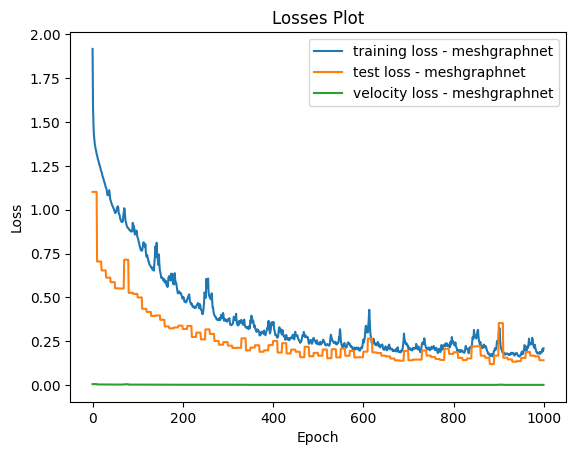

In [10]:
post.save_plots(args, losses, test_losses, velo_val_losses, postprocess_dir)

# Let's load model and animate flow field

With the methods below, we visualize the results from a model trained in this colab or a pre-trained model that we import from elsewhere.

First, let's implement functions for visualizing flow fields. The tricky part here is to plot all predicted flow velocity (x-velocity in this case) on a mesh. The built-in function of [tri](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.triplot.html) came into rescue. Triplot allows us to draw a unstructured triangular grid as lines, which suits our purpose perfectly.🌐

If you have been waiting through the two trainings, you can simply **skip the following cell** and just run through the visualization cell right after. ⏭

Or, if any of you would like to have a taste what the prediction would be like, we got you coverd. We have provided two trained models saved from above. You need to **load the models** first so that the animation functions will work properly.👇

Here we only review the **good one** (more data)

In [13]:
# load model.
args.device = torch.device('cpu') # animation function cannot work with data on GPU
num_node_features = dataset[0].x.shape[1]
num_edge_features = dataset[0].edge_attr.shape[1]
num_classes = 2 # the dynamic variables have the shape of 2 (velocity)
PATH = Path(checkpoint_dir, 'model_nl10_bs2_hd10_ep1000_wd0.0005_lr0.001_shuff_True_tr10_te2.pt')
model = m.MeshGraphNet(num_node_features, num_edge_features, args.hidden_dim, num_classes,
                            args).to(args.device)

model.load_state_dict(torch.load(PATH, map_location=args.device))

<All keys matched successfully>

Now let's us make animations 🎥 This process might take a while depending on how many frames of velocity fields are plotted.

Generating velocity fields...
12


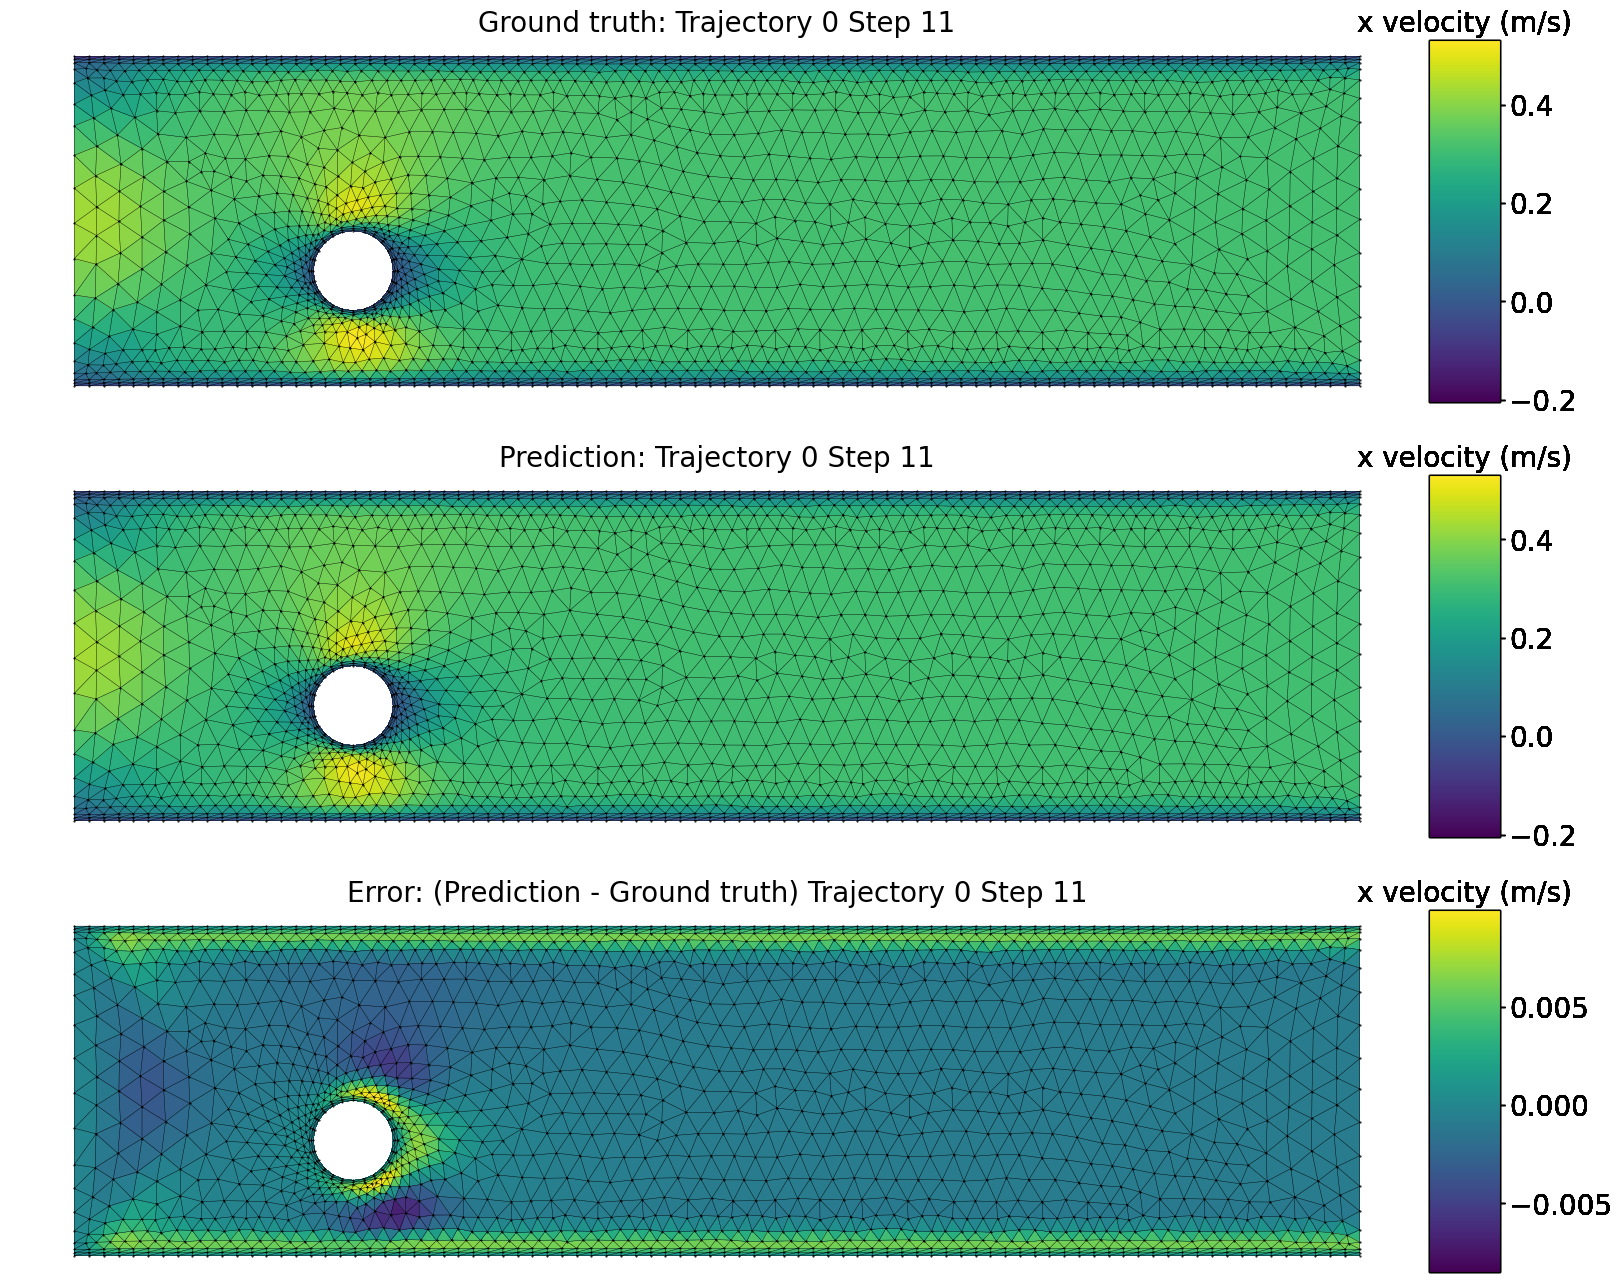

In [14]:
# visualize predicted velocities
animation_name = 'x_velocity'

eval_data_loader = post.visualize(dataset, model, animation_dir, args, animation_name, stats_list,
           delta_t = 0.01, skip = 1)

So now you have generated a gif named *x_velocity.gif* at the *animations* folder.  

You can download this gif file by clicking download on the *Folder* icon on the left side pannel. Then you can check offline.